# Пример чтения файлов формата `.bag`
В данном блокноте приведен пример чтения технических данных из Робота Unitree A1 ИТ-Центра МАИ по имени Дора.
Данный формат широко распространен для записи технических параметров в системах ROS

Установка необходимых пакетов (могут быть проблемы при установке)

In [13]:
# %pip install bagpy

Подключаем необходимые библиотеки:

In [14]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.titlesize'] = 10
plt.rcParams['axes.titlesize'] = 10
import numpy as np

In [15]:
b = bagreader("./20230117_183740.bag")

[INFO]  Successfully created the data folder ./20230117_183740.


Посмотрим какие данные сохранены в файле

In [16]:
#Если хотим посмотреть все топики в файле
#pd.set_option('display.max_rows', None)
b.topic_table

,Topics,Types,Message Count,Frequency
0,/device_0/info,diagnostic_msgs/KeyValue,13,NaN
1,/device_0/sensor_0/Depth_0/image/data,sensor_msgs/Image,394,14.988542
2,/device_0/sensor_0/Depth_0/image/metadata,diagnostic_msgs/KeyValue,9456,NaN
3,/device_0/sensor_0/Depth_0/info,realsense_msgs/StreamInfo,1,NaN
4,/device_0/sensor_0/Depth_0/info/camera_info,sensor_msgs/CameraInfo,1,NaN
...,...,...,...,...
102,/device_0/sensor_2/option/Frames_Queue_Size/de...,std_msgs/String,1,NaN
103,/device_0/sensor_2/option/Frames_Queue_Size/value,std_msgs/Float32,1,NaN
104,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/String,1,NaN
105,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/Float32,1,NaN


## Декодирование сообщений из топика

In [17]:
msgsImu_MSG = b.message_by_topic('/device_0/sensor_2/Gyro_0/imu/data')
msgsImu_MSG

'./20230117_183740/device_0-sensor_2-Gyro_0-imu-data.csv'

In [18]:
df_msgsImu = pd.read_csv(msgsImu_MSG)
df_msgsImu

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,...,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000015,92990,1673969860,237489462,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.005167,92991,1673969860,242477894,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.009925,92992,1673969860,247466326,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.014939,92993,1673969860,252454519,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.020369,92994,1673969860,257442951,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5026,26.270654,98250,1673969886,500195026,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5027,26.275579,98251,1673969886,505174637,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5028,26.280564,98252,1673969886,510154009,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5029,26.285781,98253,1673969886,515133381,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
df_msgsImu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5031 entries, 0 to 5030
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Time                              5031 non-null   float64
 1   header.seq                        5031 non-null   int64  
 2   header.stamp.secs                 5031 non-null   int64  
 3   header.stamp.nsecs                5031 non-null   int64  
 4   header.frame_id                   5031 non-null   int64  
 5   orientation.x                     5031 non-null   float64
 6   orientation.y                     5031 non-null   float64
 7   orientation.z                     5031 non-null   float64
 8   orientation.w                     5031 non-null   float64
 9   orientation_covariance_0          5031 non-null   float64
 10  orientation_covariance_1          5031 non-null   float64
 11  orientation_covariance_2          5031 non-null   float64
 12  orient

Построим график для линейного ускорения датчика по оси Y.
Обратите внимание, что датчик в процессе эксперимента не перемещался, на него воздействовали лишь вибрации от вентилляторов, расположенных в корпусе робота.

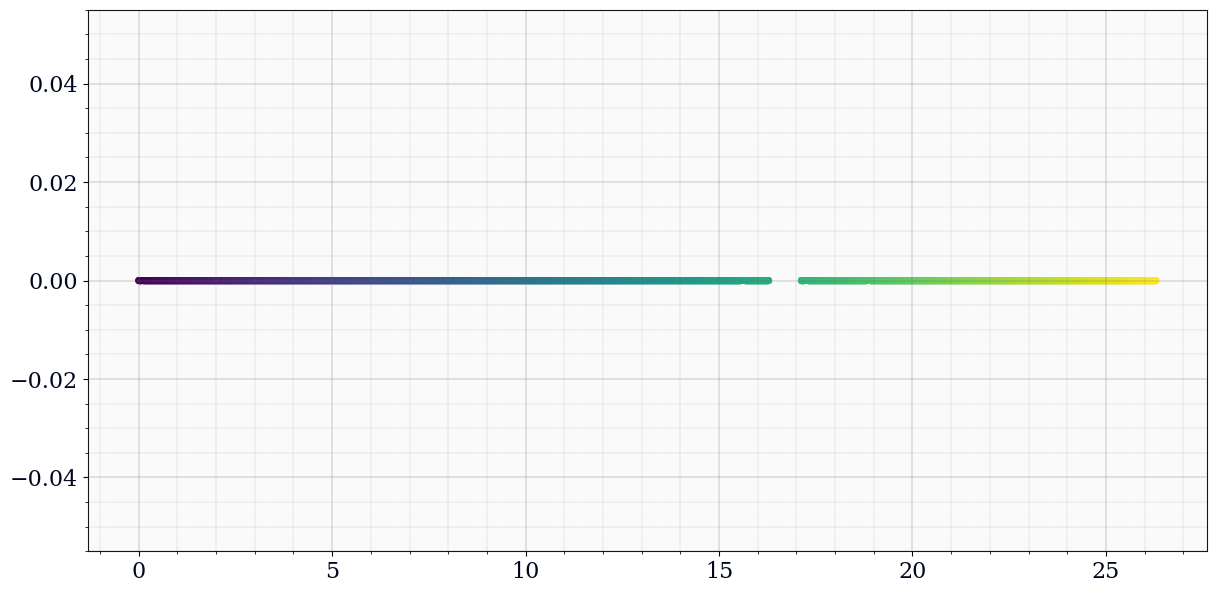

In [20]:
fig, ax = bagpy.create_fig(1)
ax[0].scatter(x='Time', y='linear_acceleration.y', data=df_msgsImu, s= 17, c = 'Time')
plt.show()

## Заглянем в цветную камеру и камеру глубины
На борту робота установлена цветная камера и камера глубины, которые осуществляли съемку в процессе записи bag файла. Доступ к данным можно получить аналогичным способом

In [21]:
sensor_msgsImage_MSG_depth = b.message_by_topic('/device_0/sensor_0/Depth_0/image/data')
sensor_msgsImage_MSG_rgb = b.message_by_topic('/device_0/sensor_1/Color_0/image/data')
sensor_msgsImage_MSG_rgb

'./20230117_183740/device_0-sensor_1-Color_0-image-data.csv'

In [22]:
df_sensor_msgsImage = pd.read_csv(sensor_msgsImage_MSG_rgb)
df_sensor_msgsImage

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.039579,6994,1673969860,210257769,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8d\x94\x8d\x8c...
1,0.106640,6995,1673969860,276888609,1,480,640,rgb8,0,1920,b'\x8c\x8b\x90\x8c\x8b\x90\x8d\x8b\x95\x8c\x8a...
2,0.174092,6996,1673969860,343518496,1,480,640,rgb8,0,1920,b'\x8c\x8e\x96\x8c\x8e\x96\x8a\x8e\x95\x8a\x8e...
3,0.239945,6997,1673969860,410146952,1,480,640,rgb8,0,1920,b'\x8e\x8c\x96\x8d\x8b\x95\x8d\x8b\x95\x8c\x8a...
4,0.307951,6998,1673969860,476774216,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8a\x93\x90\x8b...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.994066,7383,1673969886,155333042,1,480,640,rgb8,0,1920,b'\x88\x89\x91\x87\x88\x90\x87\x85\x8f\x88\x87...
390,26.058981,7384,1673969886,221859217,1,480,640,rgb8,0,1920,b'\x86\x8b\x8f\x85\x8a\x8e\x89\x88\x8f\x89\x88...
391,26.128662,7385,1673969886,288382292,1,480,640,rgb8,0,1920,b'\x86\x8c\x8d\x86\x8c\x8d\x84\x89\x8b\x86\x8c...
392,26.192559,7386,1673969886,354902267,1,480,640,rgb8,0,1920,b'\x87\x86\x8d\x87\x86\x8d\x88\x87\x8e\x88\x87...


In [23]:
df_sensor_msgsImage_depth = pd.read_csv(sensor_msgsImage_MSG_depth)
df_sensor_msgsImage_depth

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.033964,6991,1673969860,210136890,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
1,0.101118,6992,1673969860,276767731,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
2,0.167259,6993,1673969860,343397617,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
3,0.234002,6994,1673969860,410026073,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
4,0.300807,6995,1673969860,476653337,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.986207,7380,1673969886,155212402,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
390,26.053176,7381,1673969886,221738577,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
391,26.119521,7382,1673969886,288261414,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
392,26.186304,7383,1673969886,354781628,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...


Далее можно считать изображение из Pandas DataFrame, однако в таком формате его использовать неудобно, поэтому добавим немного магии для преобразования в удобный вид цветного изображения

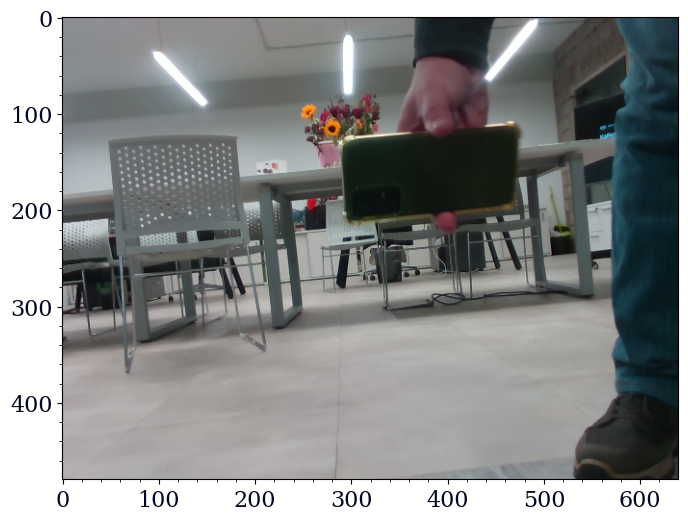

In [24]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage['data'][190]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

Ещё больше магии применим для преобразования изображения с карты глубины встроенной камеры Intel Realsence

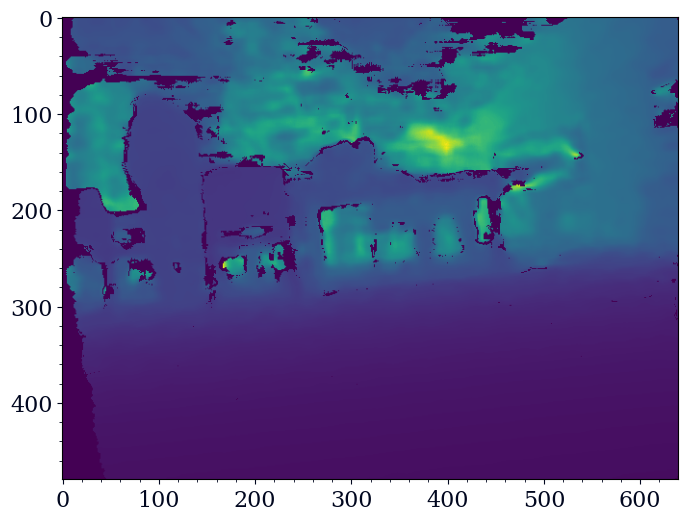

In [25]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage_depth['data'][0]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.view(np.uint16).reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

## Практическое задание
* Попробуйте считать какие-либо параметры датчиков из данного файла, например, акселерометра
* Постройте параметры в виде графиков в matplotlib

In [36]:
plt.rcParams.update({
    'figure.titlesize': 11,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

imu_path = b.message_by_topic('/device_0/sensor_2/Gyro_0/imu/data')
df_imu = pd.read_csv(imu_path)
t = df_imu['Time']
ax_a, ay_a, az_a = df_imu['linear_acceleration.x'], df_imu['linear_acceleration.y'], df_imu['linear_acceleration.z']
wx, wy, wz = df_imu['angular_velocity.x'], df_imu['angular_velocity.y'], df_imu['angular_velocity.z']



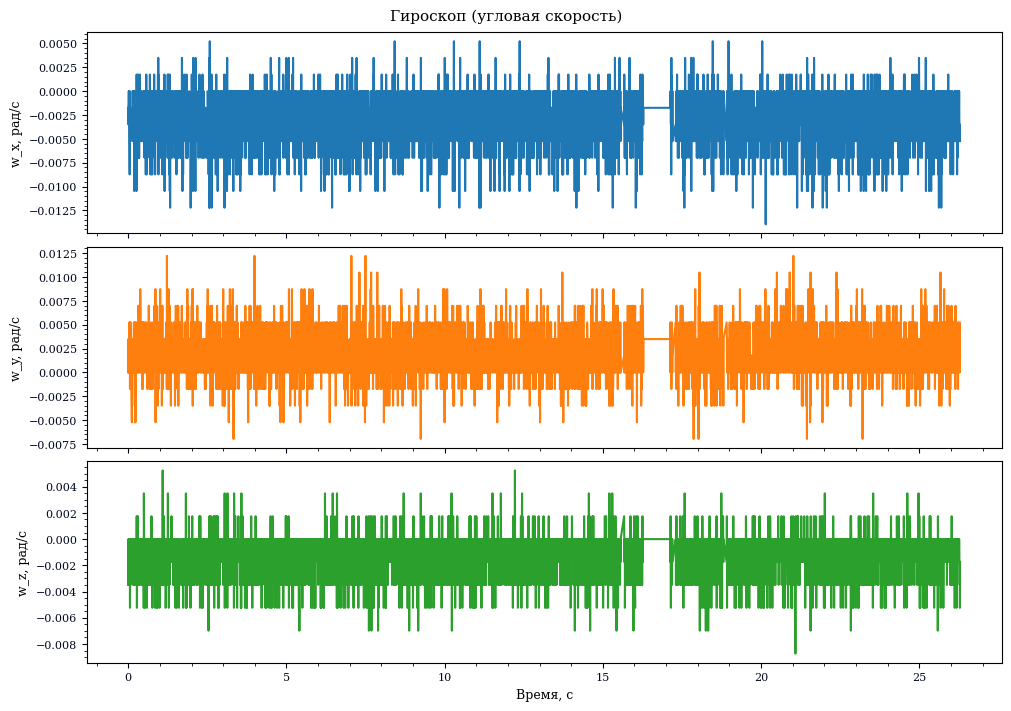

In [38]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 7), constrained_layout=True)
axes[0].plot(t, wx, color='C0')
axes[0].set_ylabel('w_x, рад/с')
axes[1].plot(t, wy, color='C1')
axes[1].set_ylabel('w_y, рад/с')
axes[2].plot(t, wz, color='C2')
axes[2].set_ylabel('w_z, рад/с')
axes[2].set_xlabel('Время, с')
fig.suptitle('Гироскоп (угловая скорость)')
plt.show()



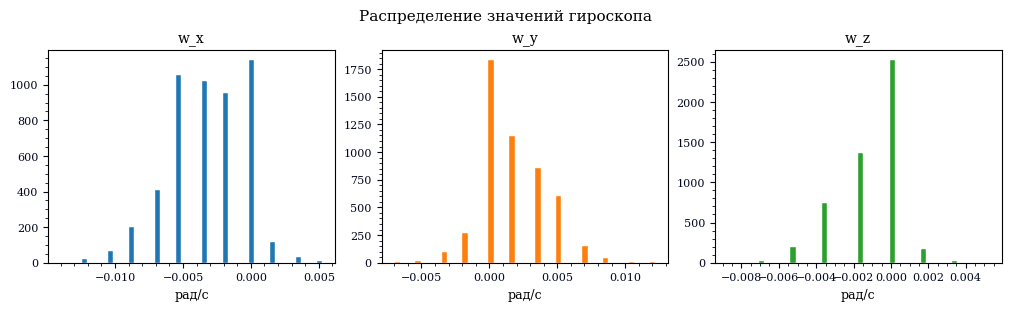

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
axes[0].hist(wx, bins=50, color='C0', edgecolor='white', linewidth=0.3)
axes[0].set_title('w_x')
axes[0].set_xlabel('рад/с')
axes[1].hist(wy, bins=50, color='C1', edgecolor='white', linewidth=0.3)
axes[1].set_title('w_y')
axes[1].set_xlabel('рад/с')
axes[2].hist(wz, bins=50, color='C2', edgecolor='white', linewidth=0.3)
axes[2].set_title('w_z')
axes[2].set_xlabel('рад/с')
fig.suptitle('Распределение значений гироскопа')
plt.show()



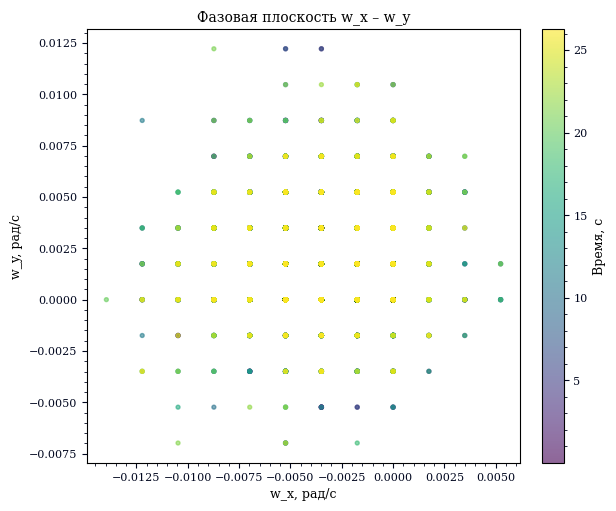

In [42]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sc = ax.scatter(wx, wy, c=t, s=8, cmap='viridis', alpha=0.6)
ax.set_xlabel('w_x, рад/с')
ax.set_ylabel('w_y, рад/с')
ax.set_title('Фазовая плоскость w_x – w_y')
ax.set_aspect('equal', adjustable='box')
plt.colorbar(sc, ax=ax, label='Время, с')
plt.show()



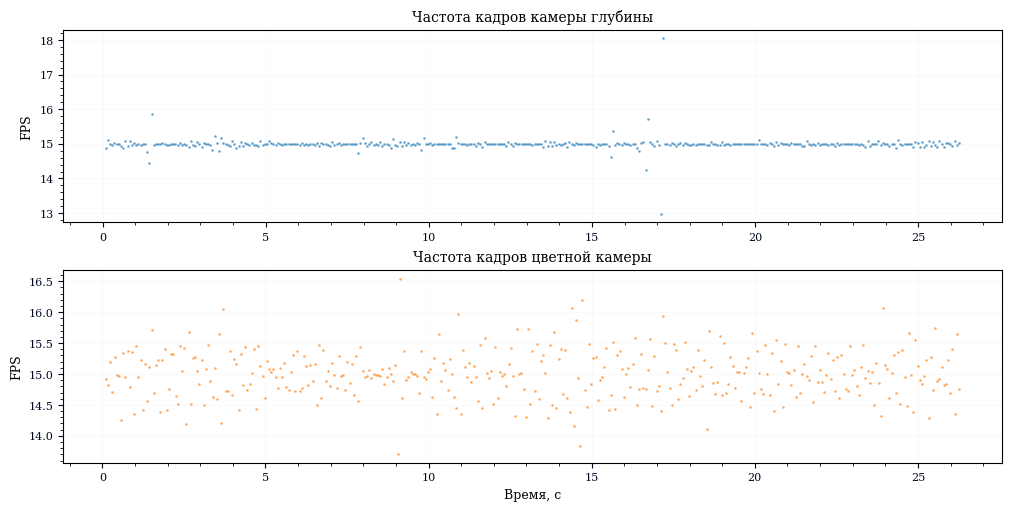

In [ ]:
fps_depth = 1.0 / np.diff(td)
fps_color = 1.0 / np.diff(tc)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), constrained_layout=True)
axes[0].plot(td.iloc[1:], fps_depth, '.', markersize=2, alpha=0.5, color='C0')
axes[0].set_ylabel('FPS')
axes[0].set_title('Частота кадров камеры глубины')
axes[1].plot(tc.iloc[1:], fps_color, '.', markersize=2, alpha=0.5, color='C1')
axes[1].set_xlabel('Время, с')
axes[1].set_ylabel('FPS')
axes[1].set_title('Частота кадров цветной камеры')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.show()



## Дополнительная информация
Дополнительная информация по данному пакету доступна по [ссылке](https://pypi.org/project/bagpy/)